# Private Topics — Result Exploration

Loads all available private-topic results (small models complete, large models partially done).  
Excludes 5 noisy topics. Compares topic coverage against the curated `PRIVATE_TOPICS` list.

In [1]:
import sys, glob
sys.path.insert(0, '..')

import numpy as np
import pandas as pd

RESULTS_DIR = '../experiments/results'

# Topics excluded from analysis (noisy / ambiguous in political context)
EXCLUDED = {'reborn', 'marwht', 'helpful', 'helpfulnv', 'helpfulv'}

# Curated private-topic list
PRIVATE_TOPICS = {
    # Sexual behaviour
    'homosex':   'whether homosexual sex relations are wrong',
    'premarsx':  'whether sex before marriage is wrong',
    'teensex':   'whether sex before marriage for teenagers is wrong',
    'xmarsex':   'whether extramarital sex is wrong',
    'sexfreq':   'how often to have sex',
    'partners':  'how many sex partners to have in a year',
    'partnrs5':  'how many sex partners to have in the last five years',
    'frndsex':   'whether to have sex with a friend',
    'pikupsex':  'whether to have sex with a casual date',
    'paidsex':   'whether to have sex for pay',
    'othersex':  'whether to have sex with some other type of partner',
    'evpaidsx':  'whether to have ever had sex with someone who was paid or who paid for sex',
    'evstray':   'whether to have sex with someone other than a spouse while married',
    'matesex':   'whether a sex partner was a spouse or regular partner',
    'nummen':    'how many male sex partners to have since age 18',
    'numwomen':  'how many female sex partners to have since age 18',
    'acqntsex':  'whether to have sex with an acquaintance',
    'condom':    'whether to use a condom when having sex',
    # Religion
    'religimp':  'how important religion is in life',
    'relidimp':  'how important religion is to the respondent personally',
    'god':       'confidence in the existence of God',
    'savesoul':  'whether to try to convince others to accept Jesus',
    'pray':      'how often to pray',
    'attend':    'how often to attend religious services',
    'postlife':  'whether to believe in life after death',
    'bible':     'feelings about the Bible',
    'relpersn':  'to what extent to self-identify as a religious person',
    'sprtprsn':  'to what extent to self-identify as a spiritual person',
    'relexp':    'whether to have had a religious experience that changed life',
    'relidesc':  'how well religion describes one as a person',
    'relidins':  'to what extent to feel insulted when someone criticizes religion',
    'relidwe':   'how often to say we instead of they when talking about religion',
    'spanking':  'whether it is sometimes necessary to discipline a child with spanking',
    'popespks':  'whether the Pope is infallible on matters of faith and morals',
    # Family & lifestyle
    'marmakid':  'whether a single mother can raise a child as well as a married couple',
    'marpakid':  'whether a single father can raise a child as well as a married couple',
    'meovrwrk':  'whether family life suffers when men focus too much on work',
    'eldfnce':   'whether grandparents should help grandchildren financially',
    'marasian':  'how to feel about a close relative marrying an Asian American person',
    'richwork':  'whether to continue working if rich enough to live comfortably',
    'hunt':      'whether to go hunting',
    'recycle':   'how often to make a special effort to recycle',
    'raclive':   'whether there are people of the opposite race living in the neighborhood',
    'rfamlook':  'how many hours per week to spend looking after family members',
    'spfalook':  'how many hours per week a spouse spends looking after family members',
    'socbar':    'how often to go to a bar',
    'socfrend':  'how often to spend a social evening with friends',
    'socommun':  'how often to spend a social evening with neighbors',
    'socrel':    'how often to spend a social evening with relatives',
    'xmovie':    'whether to see an X-rated movie in the last year',
    'hrsrelax':  'how many hours per day to have to relax',
    'life':      'whether life is exciting, routine, or dull',
    'goodlife':  'whether standard of living will improve in the future',
    'kidssol':   "whether children's standard of living will be better or worse",
    'parsol':    "whether standard of living is better or worse than parents'",
    # Success factors
    'opwlth':    'how important coming from a wealthy family is for getting ahead in life',
    'oppared':   'how important having well-educated parents is for getting ahead in life',
    'opeduc':    'how important having a good education is for getting ahead in life',
    'ophrdwrk':  'how important hard work is for getting ahead in life',
    'opknow':    'how important knowing the right people is for getting ahead in life',
    'opclout':   'how important having political connections is for getting ahead in life',
    'oprelig':   'how important being the right religion is for getting ahead in life',
    # Science & technology
    'toofast':   'whether science makes our way of life change too fast',
    'intsci':    'how interested to be in new scientific discoveries',
    'inttech':   'how interested to be in new inventions and technologies',
    # Mental health
    'fammhneg':  'to what extent family holds negative attitudes about people with mental health problems',
    'othmhneg':  'to what extent acquaintances hold negative attitudes about people with mental health problems',
    # Misc
    'fear':      'whether to be afraid to walk alone at night in the neighborhood',
    'evcrack':   'whether to have ever used crack cocaine',
    'emailhr':   'how many hours per week to spend on email',
    'emailmin':  'how many minutes per week to spend on email',
    'wwwhr':     'how many hours per week to use the web',
    'wwwmin':    'how many minutes per week to use the web',
}
print(f'PRIVATE_TOPICS: {len(PRIVATE_TOPICS)} entries')

PRIVATE_TOPICS: 73 entries


## 1. Load All Available Results

In [10]:
import os

dfs = []

# ── Small models (all complete) ──────────────────────────────────────────────
small_csvs = sorted(glob.glob(f'{RESULTS_DIR}/exp0ab_ext_private_g*.csv'))
for f in small_csvs:
    df = pd.read_csv(f)
    dfs.append(df)
    print(f'  small  {os.path.basename(f):50s}  {len(df):5d} rows  models: {df["model"].unique().tolist()}')

# ── Large models (load final CSV if available; fall back to per-condition PKLs) ──
# Find all final large-model private CSVs
large_csvs = sorted(glob.glob(f'{RESULTS_DIR}/exp_large_private_pol_*.csv'))
loaded_models = set()
for f in large_csvs:
    df = pd.read_csv(f)
    if 'category' not in df.columns:
        df['category'] = 'private'
    dfs.append(df)
    loaded_models.update(df['model'].unique().tolist())
    print(f'  large  {os.path.basename(f):50s}  {len(df):5d} rows  models: {df["model"].unique().tolist()}')

# Per-condition PKL checkpoints (partial runs for models not yet complete)
import pickle
large_cond_pkls = sorted(glob.glob(f'{RESULTS_DIR}/exp_large_private_pol_*_rhetorical_*.pkl'))
large_cond_pkls += sorted(glob.glob(f'{RESULTS_DIR}/exp_large_private_pol_*_stance_*.pkl'))
large_cond_pkls += sorted(glob.glob(f'{RESULTS_DIR}/exp_large_private_pol_*_survey_*.pkl'))
for f in large_cond_pkls:
    df = pickle.load(open(f, 'rb'))
    if not isinstance(df, pd.DataFrame) or len(df) == 0:
        continue
    model_names = df['model'].unique().tolist() if 'model' in df.columns else []
    if all(m in loaded_models for m in model_names):
        continue  # already loaded from final CSV
    if 'category' not in df.columns:
        df['category'] = 'private'
    dfs.append(df)
    loaded_models.update(model_names)
    print(f'  pkl    {os.path.basename(f):50s}  {len(df):5d} rows  models: {model_names}')

df_all = pd.concat(dfs, ignore_index=True)
print(f'\nTotal loaded: {len(df_all)} rows')
print(f'Models ({df_all["model"].nunique()}): {sorted(df_all["model"].unique())}')
print(f'Conditions: {sorted(df_all["condition"].unique())}')
print(f'Topics: {df_all["topic"].nunique()} unique')

  small  exp0ab_ext_private_g1_20260223_102822.csv             588 rows  models: ['Gemma-2-9b_base', 'Gemma-2-9b_instruct']
  small  exp0ab_ext_private_g2_20260223_102822.csv             588 rows  models: ['Llama-3.1-8B_base', 'Llama-3.1-8B_instruct']
  small  exp0ab_ext_private_g3_20260223_104115.csv             882 rows  models: ['Qwen3-4B_base', 'Qwen3-4B_instruct', 'Qwen3-4B_reasoning']
  small  exp0ab_ext_private_g4_20260223_112228.csv             882 rows  models: ['SmolLM3-3B_base', 'SmolLM3-3B_instruct', 'SmolLM3-3B_reasoning']
  large  exp_large_private_pol_Mistral-Small-24B_20260223_112801.csv    294 rows  models: ['Mistral-Small-24B']

Total loaded: 3234 rows
Models (11): ['Gemma-2-9b_base', 'Gemma-2-9b_instruct', 'Llama-3.1-8B_base', 'Llama-3.1-8B_instruct', 'Mistral-Small-24B', 'Qwen3-4B_base', 'Qwen3-4B_instruct', 'Qwen3-4B_reasoning', 'SmolLM3-3B_base', 'SmolLM3-3B_instruct', 'SmolLM3-3B_reasoning']
Conditions: ['rhetorical', 'stance', 'survey']
Topics: 98 unique


In [11]:
# in df_all, filter where gss_polarization is not null and not zero
df_filtered = df_all[df_all['gss_polarization'].notna() & (df_all['gss_polarization'] != 0)]
# then filter topics EXCLUDED
df_filtered = df_filtered[~df_filtered['topic'].isin(EXCLUDED)]

In [12]:
df_all = df_filtered

## 2. Topic List Comparison: Results vs PRIVATE_TOPICS

In [13]:
result_topics = set(df_all['topic'].unique())
curated_topics = set(PRIVATE_TOPICS.keys())

in_results_only = sorted(result_topics - curated_topics)
in_curated_only = sorted(curated_topics - result_topics)
in_both = result_topics & curated_topics
in_excluded = result_topics & EXCLUDED

print(f'Topics in results:          {len(result_topics)}')
print(f'Topics in PRIVATE_TOPICS:   {len(curated_topics)}')
print(f'Overlap:                    {len(in_both)}')
print(f'Excluded (always dropped):  {sorted(in_excluded)}')
print()
print(f'=== In results but NOT in PRIVATE_TOPICS ({len(in_results_only)}) ===')
for t in in_results_only:
    tag = '  [EXCLUDED]' if t in EXCLUDED else ''
    print(f'  {t}{tag}')
print()
if in_curated_only:
    print(f'=== In PRIVATE_TOPICS but NOT in results ({len(in_curated_only)}) ===')
    for t in in_curated_only:
        print(f'  {t}')
else:
    print('All PRIVATE_TOPICS are present in results.')

Topics in results:          73
Topics in PRIVATE_TOPICS:   73
Overlap:                    73
Excluded (always dropped):  []

=== In results but NOT in PRIVATE_TOPICS (0) ===

All PRIVATE_TOPICS are present in results.


## 3. Filter: Exclude 5 Topics, Restrict to PRIVATE_TOPICS

In [14]:
df = df_all[
    (~df_all['topic'].isin(EXCLUDED)) &
    (df_all['topic'].isin(curated_topics))
].copy()

print(f'After filtering: {len(df)} rows')
print(f'Topics: {df["topic"].nunique()} unique')
print(f'Models: {sorted(df["model"].unique())}')

After filtering: 2409 rows
Topics: 73 unique
Models: ['Gemma-2-9b_base', 'Gemma-2-9b_instruct', 'Llama-3.1-8B_base', 'Llama-3.1-8B_instruct', 'Mistral-Small-24B', 'Qwen3-4B_base', 'Qwen3-4B_instruct', 'Qwen3-4B_reasoning', 'SmolLM3-3B_base', 'SmolLM3-3B_instruct', 'SmolLM3-3B_reasoning']


## 4. Pearson r: Activation Polarization vs GSS Survey Polarization

In [17]:
def pearson_r(x, y):
    """Pearson r, dropping NaN pairs."""
    mask = ~(np.isnan(x) | np.isnan(y))
    if mask.sum() < 5:
        return np.nan, mask.sum()
    return np.corrcoef(x[mask], y[mask])[0, 1], mask.sum()

records = []
for (model, cond), grp in df.groupby(['model', 'condition']):
    row_info = grp.iloc[0]
    r_all, n_all = pearson_r(grp['mahal_all'].values, grp['gss_polarization'].values)
    r_mid, _    = pearson_r(grp['mahal_mid10'].values, grp['gss_polarization'].values)
    records.append({
        'model':      model,
        'family':     row_info.get('family', model),
        'model_type': row_info.get('model_type', '?'),
        'condition':  cond,
        'n_topics':   n_all,
        'r_all':      round(r_all, 3),
        'r_mid10':    round(r_mid, 3),
    })

corr = pd.DataFrame(records).sort_values(['model_type', 'family', 'condition'])
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.width', 200)
corr.to_csv('../experiments/results/private_topic_correlations.csv', index=False)

## 5. Pivot: Best Condition per Model

In [16]:
pivot = corr.pivot_table(
    index=['model', 'model_type'],
    columns='condition',
    values='r_all',
    aggfunc='first'
).round(3)
pivot['best'] = pivot.max(axis=1)
pivot['best_cond'] = pivot[['rhetorical', 'stance', 'survey']].idxmax(axis=1)
pivot = pivot.sort_values(['model_type', 'best'], ascending=[True, False])
pivot

,condition,rhetorical,stance,survey,best,best_cond
model,model_type,,,,,
Llama-3.1-8B_base,base,0.480,0.225,0.295,0.480,rhetorical
SmolLM3-3B_base,base,0.318,0.370,0.414,0.414,survey
Gemma-2-9b_base,base,0.376,0.305,0.401,0.401,survey
Qwen3-4B_base,base,0.346,0.229,0.356,0.356,survey
Llama-3.1-8B_instruct,instruct,0.613,0.693,0.465,0.693,stance
Gemma-2-9b_instruct,instruct,0.647,0.627,0.522,0.647,rhetorical
Mistral-Small-24B,instruct,0.588,0.630,0.396,0.630,stance
SmolLM3-3B_instruct,instruct,0.508,0.535,0.451,0.535,stance
Qwen3-4B_instruct,instruct,0.503,0.488,0.420,0.503,rhetorical


## 6. Summary by Model Type

In [18]:
print('=== Mean r_all by model_type (averaged over conditions and families) ===')
print(corr.groupby('model_type')[['r_all', 'r_mid10']].mean().round(3))

print('\n=== Mean r_all by family x model_type ===')
print(corr.groupby(['family', 'model_type'])[['r_all', 'r_mid10']].mean().round(3))

=== Mean r_all by model_type (averaged over conditions and families) ===
            r_all  r_mid10
model_type                
base        0.343    0.368
instruct    0.539    0.564
reasoning   0.464    0.458

=== Mean r_all by family x model_type ===
                              r_all  r_mid10
family            model_type                
Gemma-2-9b        base        0.361    0.364
                  instruct    0.599    0.586
Llama-3.1-8B      base        0.333    0.317
                  instruct    0.590    0.640
Mistral-Small-24B instruct    0.538    0.596
Qwen3-4B          base        0.310    0.332
                  instruct    0.470    0.414
                  reasoning   0.366    0.311
SmolLM3-3B        base        0.367    0.457
                  instruct    0.498    0.583
                  reasoning   0.563    0.605


## 7. Topic-Level Rankings (Best Model, by Topic)

In [19]:
# For each topic, what's the mean activation polarization across all model × condition combos?
topic_stats = (
    df.dropna(subset=['mahal_all', 'gss_polarization'])
    .groupby('topic')
    .agg(
        mean_mahal=('mahal_all', 'mean'),
        mean_gss=('gss_polarization', 'mean'),
        n_models=('model', 'nunique'),
    )
    .reset_index()
)
topic_stats['desc'] = topic_stats['topic'].map(PRIVATE_TOPICS)
topic_stats = topic_stats.sort_values('mean_gss', ascending=False)

print('Top 20 topics by GSS polarization:')
print(topic_stats.head(20)[['topic', 'desc', 'mean_gss', 'mean_mahal', 'n_models']].to_string(index=False))

print('\nBottom 10 topics by GSS polarization:')
print(topic_stats.tail(10)[['topic', 'desc', 'mean_gss', 'mean_mahal', 'n_models']].to_string(index=False))

Top 20 topics by GSS polarization:
   topic                                                                    desc  mean_gss  mean_mahal  n_models
 homosex                              whether homosexual sex relations are wrong     0.325       2.056        11
religimp                                       how important religion is in life     0.227       1.904        11
savesoul                       whether to try to convince others to accept Jesus     0.223       1.833        11
premarsx                                    whether sex before marriage is wrong     0.196       1.927        11
relidimp                  how important religion is to the respondent personally     0.193       1.904        11
spanking   whether it is sometimes necessary to discipline a child with spanking     0.193       1.943        11
     god                                      confidence in the existence of God     0.189       1.861        11
 teensex                      whether sex before marriage for

## 8. Scatter: Activation Polarization vs GSS Polarization (Best Instruct Models)

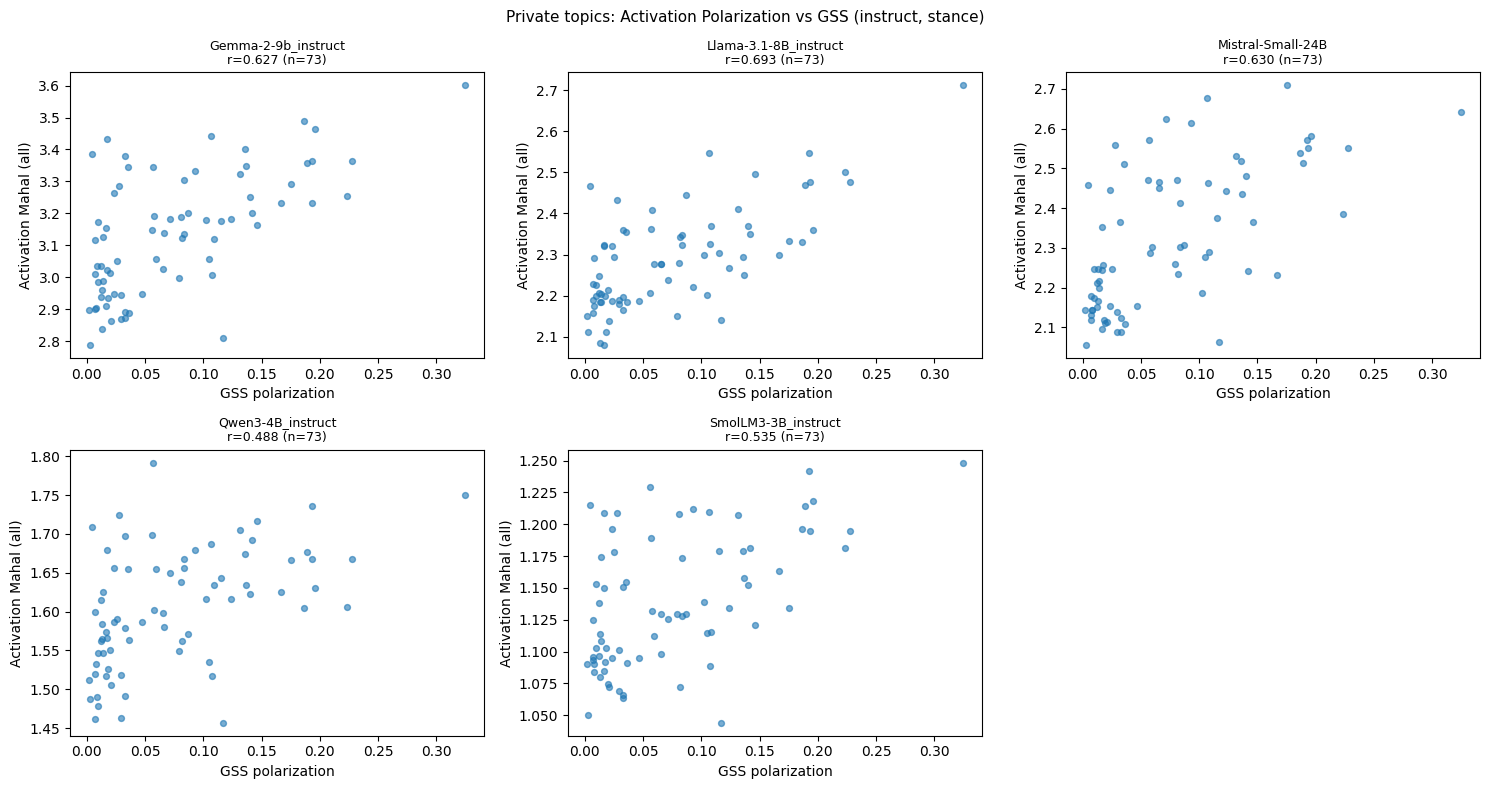

In [20]:
import matplotlib.pyplot as plt

# Pick instruct models, stance condition
plot_df = df[(df['condition'] == 'stance') & (df['model_type'] == 'instruct')].dropna(subset=['mahal_all', 'gss_polarization'])
models = sorted(plot_df['model'].unique())

ncols = min(3, len(models))
nrows = (len(models) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)

for i, model in enumerate(models):
    ax = axes[i // ncols][i % ncols]
    sub = plot_df[plot_df['model'] == model]
    r, n = pearson_r(sub['mahal_all'].values, sub['gss_polarization'].values)
    ax.scatter(sub['gss_polarization'], sub['mahal_all'], s=18, alpha=0.6)
    ax.set_title(f'{model}\nr={r:.3f} (n={n})', fontsize=9)
    ax.set_xlabel('GSS polarization')
    ax.set_ylabel('Activation Mahal (all)')

# Hide unused axes
for j in range(len(models), nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

plt.suptitle('Private topics: Activation Polarization vs GSS (instruct, stance)', fontsize=11)
plt.tight_layout()
plt.show()